### Step 1 — Select Data

Choose the CSV for the experiment under test by setting DATA_PATH.


In [1]:
# Step 1: Set the data path for the selected experiment.
DATA_PATH = "./executed/2026-ICSA-PE/unbalanced_processing/unbalanced_processing.csv"


### Step 2 — Load & Inspect

Import libraries, load the measurements, and quickly inspect the table to understand available columns.


In [2]:
# Step 2: Import analysis dependencies and inspect the raw measurement table.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan, normal_ad

# Keep numeric output readable across the entire notebook.
pd.set_option("display.float_format", lambda v: f"{v:,.6f}")
PATH = DATA_PATH
# Step 2a: Load the merged dataset and parse timestamps for optional time-aware plots.
df = pd.read_csv(PATH)
if "timestamp" in df.columns:
    df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
# Provide a quick head/info snapshot so downstream cells know what columns exist.
display(df.head(3))
df.info()

# Step 3: Filter to active samples, then compute descriptive statistics and correlations.
df_active = df[(df["cpu_power"] > 0) & (df["requests_per_s"] > 0)].copy()
print(f"Active samples: {len(df_active)} / {len(df)}")
# The next line drops initial warm-up seconds until the number of users is stable.
df_active = df_active[df_active["seconds_from_start"] >= 120].copy()
cols = ["cpu_power", "latency", "requests_per_s", "cpu_utilization"]
print("Summary (active rows):")
display(df_active[cols].describe())
print("\nCorrelation matrix (Pearson):")
display(df_active[cols].corr(method="pearson"))
print("\nCorrelation matrix (Spearman):")
display(df_active[cols].corr(method="spearman"))


,timestamp,cpu_utilization,cpu_power,dram_w,memory_usage,container_id,container_name,seconds_from_start,requests_per_s,failures_per_s,latency_p50_ms,latency,run_id,experiment_name
0,2025-11-22 09:45:59+00:00,0.000000,0.000000,0.295287,21266432,0a52b9366868133287b7d730a373058dc30348c216fa20...,202511220945-testunbalanced1_server.1.u859tmbl...,0.000000,0.000000,0.000000,0.000000,0.000000,1,202511220945-testunbalanced1
1,2025-11-22 09:46:00+00:00,0.000000,0.000000,0.303894,21266432,0a52b9366868133287b7d730a373058dc30348c216fa20...,202511220945-testunbalanced1_server.1.u859tmbl...,1.000000,0.000000,0.000000,0.000000,0.000000,1,202511220945-testunbalanced1
2,2025-11-22 09:46:01+00:00,0.000000,0.000000,0.301269,21266432,0a52b9366868133287b7d730a373058dc30348c216fa20...,202511220945-testunbalanced1_server.1.u859tmbl...,2.000000,0.000000,0.000000,0.000000,0.000000,1,202511220945-testunbalanced1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36509 entries, 0 to 36508
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype              
---  ------              --------------  -----              
 0   timestamp           36509 non-null  datetime64[ns, UTC]
 1   cpu_utilization     36509 non-null  float64            
 2   cpu_power           36509 non-null  float64            
 3   dram_w              36509 non-null  float64            
 4   memory_usage        36509 non-null  int64              
 5   container_id        36509 non-null  object             
 6   container_name      36509 non-null  object             
 7   seconds_from_start  36509 non-null  float64            
 8   requests_per_s      36509 non-null  float64            
 9   failures_per_s      36509 non-null  float64            
 10  latency_p50_ms      36509 non-null  float64            
 11  latency             36509 non-null  float64            
 12  run_id              36509 non-nu

,cpu_power,latency,requests_per_s,cpu_utilization
count,"32,910.000000","32,910.000000","32,910.000000","32,910.000000"
mean,18.891262,"12,994.165907",0.749681,0.251400
std,0.459149,81.925804,0.050012,0.003732
min,11.108520,"12,000.000000",0.600000,0.245000
25%,18.569870,"13,000.000000",0.700000,0.250000
50%,18.847850,"13,000.000000",0.700000,0.250000
75%,19.177470,"13,000.000000",0.800000,0.252530
max,23.984380,"14,000.000000",0.800000,0.274730



Correlation matrix (Pearson):


,cpu_power,latency,requests_per_s,cpu_utilization
cpu_power,1.000000,-0.013465,0.013873,0.325487
latency,-0.013465,1.000000,-0.019737,0.004311
requests_per_s,0.013873,-0.019737,1.000000,0.020883
cpu_utilization,0.325487,0.004311,0.020883,1.000000



Correlation matrix (Spearman):


,cpu_power,latency,requests_per_s,cpu_utilization
cpu_power,1.000000,-0.009234,0.009530,0.339510
latency,-0.009234,1.000000,-0.018978,0.001709
requests_per_s,0.009530,-0.018978,1.000000,0.031319
cpu_utilization,0.339510,0.001709,0.031319,1.000000


### Step 3 — Visualize Scatter

Plot latency versus CPU power and fit a simple least-squares line to eyeball the relationship.


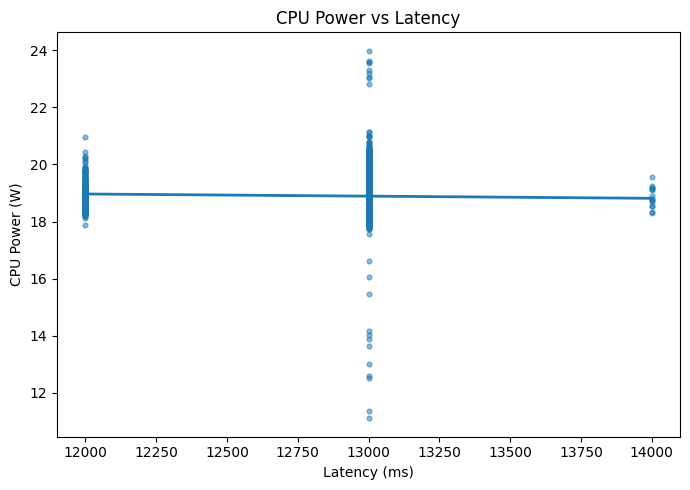

In [3]:
# Step 3: Visualize the latency-power scatter with a simple least-squares fit.
x = df_active["latency"].values
y = df_active["cpu_power"].values
# Fit a 2-parameter line (slope, intercept) purely for visualization.
A = np.vstack([x, np.ones_like(x)]).T
slope, intercept = np.linalg.lstsq(A, y, rcond=None)[0]
plt.figure(figsize=(7, 5))
plt.scatter(x, y, alpha=0.5, s=12)
xline = np.linspace(x.min(), x.max(), 200)
plt.plot(xline, slope * xline + intercept, linewidth=2)
plt.xlabel("Latency (ms)")
plt.ylabel("CPU Power (W)")
plt.title("CPU Power vs Latency")
plt.tight_layout()
plt.show()


### Step 4 — OLS with Controls

Fit an OLS model for CPU power using latency plus throughput and CPU utilization as controls.


In [4]:
# Step 4: Run an OLS regression controlling for throughput and CPU utilization.
X = df_active[["latency", "requests_per_s", "cpu_utilization"]].copy()
# Add an intercept term because statsmodels does not include one by default.
X = sm.add_constant(X)
y = df_active["cpu_power"].copy()
ols = sm.OLS(y, X).fit()
print(ols.summary())


                            OLS Regression Results                            
Dep. Variable:              cpu_power   R-squared:                       0.106
Model:                            OLS   Adj. R-squared:                  0.106
Method:                 Least Squares   F-statistic:                     1303.
Date:                Mon, 08 Dec 2025   Prob (F-statistic):               0.00
Time:                        18:50:42   Log-Likelihood:                -19233.
No. Observations:               32910   AIC:                         3.847e+04
Df Residuals:                   32906   BIC:                         3.851e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               9.8525      0.414     

### Step 5 — Robust Standard Errors

Recompute coefficients with HC3 robust errors to hedge against heteroskedasticity.


In [5]:
# Step 5: Recompute coefficients using HC3 robust standard errors.
ols_robust = ols.get_robustcov_results(cov_type="HC3")
robust_ci = ols_robust.conf_int()
robust_table = pd.DataFrame({
    "variable": ols_robust.model.exog_names,
    "coef": ols_robust.params,
    "std_err": ols_robust.bse,
    "t_value": ols_robust.tvalues,
    "p_value": ols_robust.pvalues,
    "ci_low": robust_ci[:, 0],
    "ci_high": robust_ci[:, 1],
})
display(robust_table)
print("HC3 covariance used; Wald/F-stat omitted to avoid singular constraint warnings.")


,variable,coef,std_err,t_value,p_value,ci_low,ci_high
0,const,9.852506,0.459901,21.423110,0.000000,8.951084,10.753928
1,latency,-0.000083,0.000033,-2.516422,0.011860,-0.000147,-0.000018
2,requests_per_s,0.062310,0.047896,1.300941,0.193288,-0.031568,0.156188
3,cpu_utilization,40.035748,0.672056,59.572038,0.000000,38.718494,41.353002


HC3 covariance used; Wald/F-stat omitted to avoid singular constraint warnings.


### Step 6 — Residual Diagnostics

Check residual normality and heteroskedasticity to validate regression assumptions.


Normality (Anderson-Darling) p-value: 0
Breusch-Pagan p-value (heteroskedasticity): 0.0444327


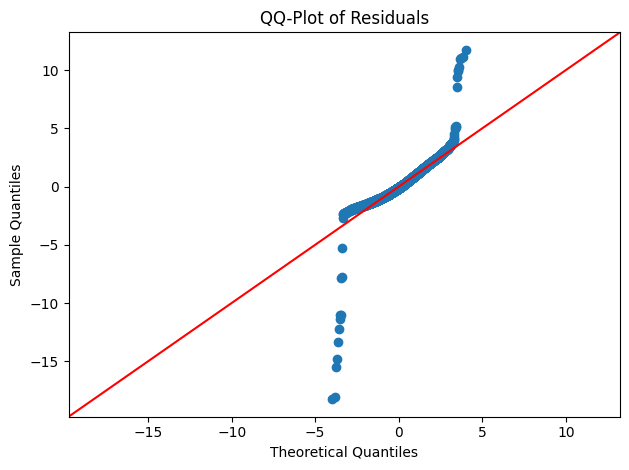

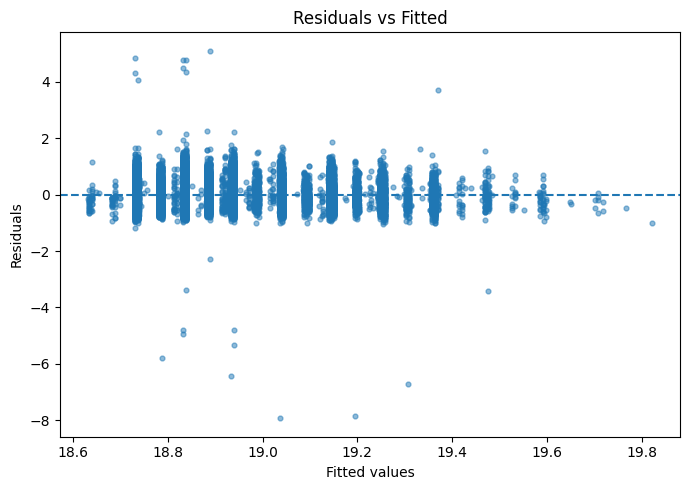

In [6]:
# Step 6: Diagnose residual behavior for normality and heteroskedasticity.
resid = ols.resid
fitted = ols.fittedvalues
# Anderson-Darling is more stable on heavy-tailed workloads than Jarque-Bera.
ad_stat, ad_p = normal_ad(resid)
print(f"Normality (Anderson-Darling) p-value: {ad_p:,.6g}")
# Breusch-Pagan flags whether the residual variance scales with the predictors.
bp_stat, bp_p, _, _ = het_breuschpagan(resid, ols.model.exog)
print(f"Breusch-Pagan p-value (heteroskedasticity): {bp_p:,.6g}")
# QQ plot for distributional shape.
sm.qqplot(resid, line="45", fit=True)
plt.title("QQ-Plot of Residuals")
plt.tight_layout()
plt.show()
# Residuals versus fitted values highlight non-linearity or variance bands.
plt.figure(figsize=(7, 5))
plt.scatter(fitted, resid, alpha=0.5, s=12)
plt.axhline(0, linestyle="--")
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted")
plt.tight_layout()
plt.show()


### Step 7 — Multicollinearity

Compute variance inflation factors to assess correlation among predictors.


In [7]:
# Step 7: Measure multicollinearity with Variance Inflation Factors (VIF).
X_no_const = df_active[["latency", "requests_per_s", "cpu_utilization"]].copy()
# VIF excludes the constant column because variance is undefined for intercept-only terms.
vif = pd.DataFrame({
    "variable": X_no_const.columns,
    "VIF": [variance_inflation_factor(X_no_const.values, i) for i in range(X_no_const.shape[1])],
})
display(vif)


,variable,VIF
0,latency,"3,978.271936"
1,requests_per_s,223.780299
2,cpu_utilization,"3,872.904832"


### Step 8 — Coefficient Summary

Summarize the latency coefficient from both classical and robust estimators.


In [8]:
# Step 8: Summarize the latency coefficient for both OLS and robust SEs.
import numpy as np
import pandas as pd

def _param_names(model):
    """Return stable parameter names independent of the statsmodels wrapper."""
    names = getattr(getattr(model, "model", None), "exog_names", None)
    if names is not None:
        return list(names)
    try:
        return list(model.params.index)
    except Exception:
        n = np.asarray(model.params).shape[0]
        return [f"x{i}" for i in range(n)]

def _safe_r2(model):
    """Extract R-squared when available, falling back to the wrapped results."""
    if hasattr(model, "rsquared"):
        return model.rsquared
    res = getattr(model, "_results", None)
    return getattr(res, "rsquared", np.nan)

def summarize_latency_effect(model, label="OLS"):
    """Collect the latency effect (beta, p-value, CI, R^2) for reporting."""
    names = _param_names(model)
    if "latency" not in names:
        raise KeyError(f"'latency' term not found. Available terms: {names}")
    idx = names.index("latency")
    params = np.asarray(model.params)
    pvals = np.asarray(model.pvalues)
    conf = np.asarray(model.conf_int())
    beta = params[idx]
    p = pvals[idx]
    ci_l, ci_h = conf[idx, 0], conf[idx, 1]
    r2 = _safe_r2(model)
    return pd.DataFrame({
        "model": [label],
        "beta_latency": [beta],
        "p_latency": [p],
        "ci_low_latency": [ci_l],
        "ci_high_latency": [ci_h],
        "R2": [r2],
    })

tbl = pd.concat([
    summarize_latency_effect(ols, "OLS"),
    summarize_latency_effect(ols_robust, "OLS (HC3 robust SEs)"),
], ignore_index=True)
display(tbl)


,model,beta_latency,p_latency,ci_low_latency,ci_high_latency,R2
0,OLS,-0.000083,0.004710,-0.000140,-0.000025,0.106209
1,OLS (HC3 robust SEs),-0.000083,0.011860,-0.000147,-0.000018,0.106209


### Step 9 — Hypothesis Decision

Render a single-line decision on whether latency significantly affects CPU power.


In [9]:
# Step 9: Produce a single-line decision on the latency hypothesis test.
alpha = 0.05
# Guard against statsmodels changes by resolving latency's position dynamically.
param_names = getattr(getattr(ols_robust, "model", None), "exog_names", None)
if param_names is None:
    param_names = list(getattr(ols_robust, "params", np.array([])))
if "latency" not in param_names:
    raise KeyError(f"'latency' not found. Available params: {param_names}")
idx_latency = param_names.index("latency")
pvals = np.asarray(ols_robust.pvalues)
p_latency = pvals[idx_latency]
decision = ("Reject H0: latency positively predicts power (p < 0.05)"
            if p_latency < alpha else "Fail to reject H0")
print(f"Hypothesis test (using robust SEs): p(latency) = {p_latency:,.6g} -> {decision}")


Hypothesis test (using robust SEs): p(latency) = 0.01186 -> Reject H0: latency positively predicts power (p < 0.05)


### Step 10 — Conclusion

Provide a brief narrative conclusion on latency's impact on CPU power for this run.


In [10]:
# Step 10: Generate a brief conclusion statement about latency's effect on CPU power.
if 'ols_robust' in globals():
    names = getattr(getattr(ols_robust, 'model', None), 'exog_names', None) or list(getattr(ols_robust, 'params', []))
    if 'latency' not in names:
        print("'latency' term not found in model; cannot summarize.")
    else:
        idx = names.index('latency')
        beta = float(ols_robust.params[idx])
        p = float(ols_robust.pvalues[idx])
        ci_low, ci_high = map(float, ols_robust.conf_int()[idx])
        r2 = getattr(ols_robust, 'rsquared', float('nan'))
        direction = 'increases' if beta > 0 else 'decreases' if beta < 0 else 'does not change'
        decision = 'Reject H0' if p < 0.05 else 'Fail to reject H0'
        print(f"Latency {direction} CPU power; beta={beta:.4f}, 95% CI [{ci_low:.4f}, {ci_high:.4f}], p={p:.4g}. {decision} at α=0.05. R²={r2:.3f} (HC3 robust SEs).")
else:
    print('Robust OLS model not found; run previous cells first.')


Latency decreases CPU power; beta=-0.0001, 95% CI [-0.0001, -0.0000], p=0.01186. Reject H0 at α=0.05. R²=0.106 (HC3 robust SEs).
